In [1]:
import sys
import os
NOTEBOOK_DIR = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(NOTEBOOK_DIR, "..")))

In [2]:
import numpy as np
import scipy
import sklearn
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import sentence_transformers
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils import dataset_utils

# Topic Classifier with RoSBERTa

## Load Data

In [3]:
REQUESTS_FILE = "../data/request_db.txt"
ADS_FILE = "../data/ads_db.txt"
MATCHING_FILE = "../data/matching_db.txt"
REQ_CATEGORIES_FILE = "../data/request_categories.txt"

In [4]:
with open(ADS_FILE, encoding="utf-8") as f:
    ads_raw = f.readlines()

In [5]:
with open(REQUESTS_FILE, encoding="utf-8") as f:
    requests_raw = f.readlines()

In [6]:
def get_req_categories(filename):
    req_categories = {}
    with open(filename, encoding="utf-8") as f:
        for line_idx, cat_info_line in enumerate(f, start=1):
            cat_info_line = cat_info_line.strip()
            if len(cat_info_line) == 0 or cat_info_line.startswith("#"):
                continue
            pos = cat_info_line.find(":")
            if pos < 0:
                raise ValueError(f"Could not find \":\" on line {line_idx}")
            cat_name = cat_info_line[:pos].strip()
            cat_info = cat_info_line[pos + 1:].strip()
    
            cat_lines = []
            for line_info in cat_info.split(","):
                line_info = line_info.strip()
                if "-" in line_info:
                    beg_str, end_str = line_info.split("-")
                    cat_lines += list(range(int(beg_str.strip()), int(end_str.strip()) + 1))
                else:
                    cat_lines.append(int(line_info))
    
            if cat_name in req_categories:
                req_categories[cat_name] = list(sorted(set(req_categories[cat_name] + cat_lines)))
            else:
                req_categories[cat_name] = list(sorted(cat_lines))
    all_lines_set = set(line for lines in req_categories.values() for line in lines)
    assert list(sorted(all_lines_set)) == list(range(1, max(all_lines_set) + 1))
    return req_categories
req_categories = get_req_categories(REQ_CATEGORIES_FILE)

In [7]:
true_markup = dataset_utils.load_matching_data(MATCHING_FILE)

## Preprocessing

In [8]:
def preprocess(text):
    text = text.replace("\\n", "\n").replace("\n", " ")
    text = text.strip()
    return text

In [9]:
ads = [preprocess(text) for text in ads_raw]
len(ads)

246

In [10]:
requests = [preprocess(text) for text in requests_raw]
len(requests)

357

## Get Embeddings

In [11]:
def calc_similarity(requests, ads):
    requests = requests / np.linalg.norm(requests, axis=1, keepdims=True)
    ads = ads / np.linalg.norm(ads, axis=1, keepdims=True)
    return np.dot(requests, ads.T)

In [12]:
def calc_distance(vec1, vec2):
    # vec1 = vec1 / np.linalg.norm(vec1)
    # vec2 = vec2 / np.linalg.norm(vec2)
    # return 1 - np.dot(vec1, vec2.T)
    dst = scipy.spatial.distance.cosine(vec1, vec2)/2  # dot product is from -1 to 1, so "1 - dot prod" is from 0 to 2
    assert dst >= 0 and dst <= 1
    return dst

In [13]:
model = sentence_transformers.SentenceTransformer("ai-forever/ru-en-RoSBERTa")

In [14]:
%%time
ad_embeddings = model.encode(ads)

CPU times: user 6min 27s, sys: 50 s, total: 7min 17s
Wall time: 1min 50s


## Calculate and Analyze Distances

### Reduce Dimension

Original RoSBERTa vector dimension (1024) looks too large for robust classification, so it is better to reduce the dimensionality, at least by PCA. Let's find the appropriate dimension value.

In [15]:
def calc_hist_distance(cat_dists, other_dists, method):
    # https://stats.stackexchange.com/q/7400

    # let's define bin size dynamically, as PCA can change scale in hardly conrollable way
    bin_size = (max(cat_dists.max(), other_dists.max()) - min(cat_dists.min(), other_dists.min()))/100

    start_pos = min(cat_dists.min(), other_dists.min()) + bin_size - (bin_size/100)
    end_pos = max(cat_dists.max(), other_dists.max())
    step = bin_size

    cat_cnt_list = []
    other_cnt_list = []
    pos = start_pos
    while pos <= end_pos:
        cat_cnt_list.append(len(cat_dists[(cat_dists > pos - bin_size) & (cat_dists <= pos)]))
        other_cnt_list.append(len(other_dists[(other_dists > pos - bin_size) & (other_dists <= pos)]))
        pos += step
    if method == "jaccard":
        dist = 1 - (
            sum(min(cat_cnt, other_cnt) for cat_cnt, other_cnt in zip(cat_cnt_list, other_cnt_list)) /
            sum(max(cat_cnt, other_cnt) for cat_cnt, other_cnt in zip(cat_cnt_list, other_cnt_list))
        )
    elif method == "hist_intersection":
        dist = 1 - (
            sum(min(cat_cnt, other_cnt) for cat_cnt, other_cnt in zip(cat_cnt_list, other_cnt_list)) /
            min(sum(cat_cnt_list), sum(other_cnt_list))
        )
    elif method == "chi-square":
        dist = (
            sum(((cat_cnt - other_cnt)**2) / max(cat_cnt + other_cnt, 1e-8) for cat_cnt, other_cnt in zip(cat_cnt_list, other_cnt_list))
        )
    else:
        raise ValueError(f"Unknown method name: {method}")
    return dist

In [16]:
def calc_int_ext_category_distances(req_lines, ad_emb_to_search):
    ad_lines = list(sorted(set(int(ad_line) - 1 for req_line in req_lines for ad_line in true_markup.get(str(req_line), []))))

    cat_dists = []
    for first_ad_idx in range(0, len(ad_lines)):
        for second_ad_idx in range(first_ad_idx + 1, len(ad_lines)):
            dist = calc_distance(ad_emb_to_search[ad_lines[first_ad_idx]], ad_emb_to_search[ad_lines[second_ad_idx]])
            cat_dists.append(dist)
    cat_dists = np.asarray(cat_dists)

    other_dists = []
    for ad_idx in range(0, len(ad_emb_to_search)):
        if ad_idx in ad_lines:
            continue
        for cat_ad_idx in ad_lines:
            dist = calc_distance(ad_emb_to_search[cat_ad_idx], ad_emb_to_search[ad_idx])
            other_dists.append(dist)
    other_dists = np.asarray(other_dists)

    return cat_dists, other_dists

In [17]:
REQ_NAME = "одежда"

pca_dims = []
hist_dists = {"jaccard": [], "hist_intersection": [], "chi-square": []}
for pca_dim in tqdm(range(1, 50)):
    pca = PCA(n_components=pca_dim)
    pca_ad_embeddings = pca.fit_transform(ad_embeddings)

    pca_cat_dists, pca_other_dists = calc_int_ext_category_distances(req_categories[REQ_NAME], pca_ad_embeddings)

    pca_dims.append(pca_dim)
    for method in hist_dists.keys():
        hist_dists[method].append(calc_hist_distance(pca_cat_dists, pca_other_dists, method))

cat_dists, other_dists = calc_int_ext_category_distances(req_categories[REQ_NAME], ad_embeddings)
orig_dist = {method: calc_hist_distance(cat_dists, other_dists, method) for method in hist_dists.keys()}

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:13<00:00,  3.64it/s]


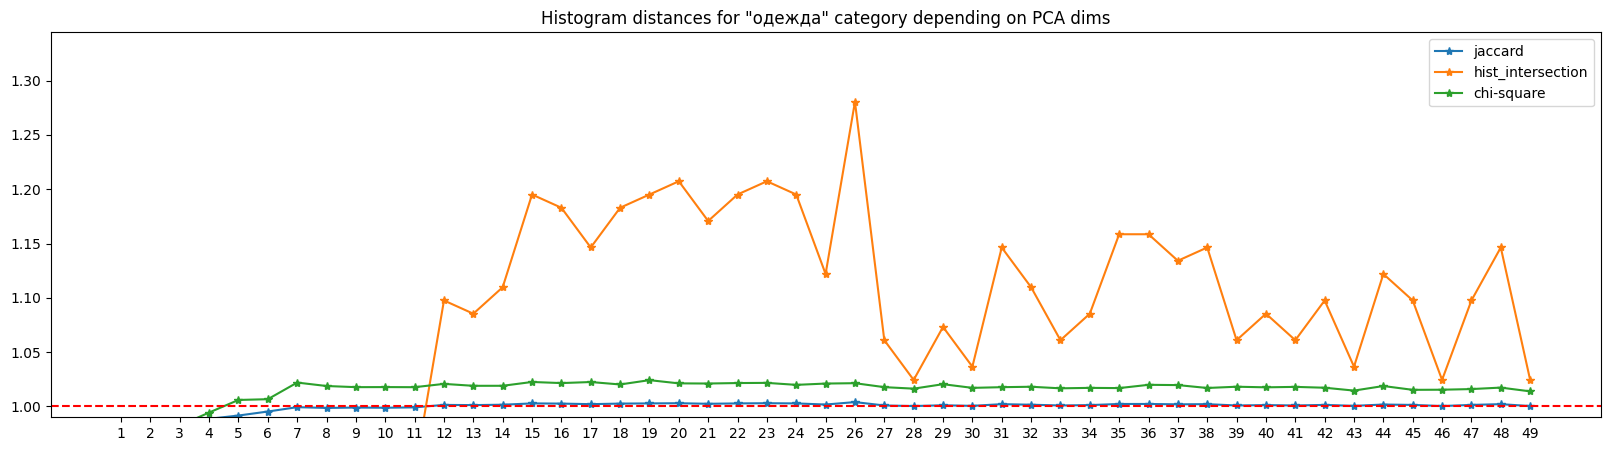

In [18]:
default_figsize = plt.rcParams['figure.figsize']
plt.rcParams['figure.figsize'] = (20, 5)

for method in hist_dists.keys():
    normed_dist = [h_dist/orig_dist[method] for h_dist in hist_dists[method]]
    plt.plot(pca_dims, normed_dist, marker="*", label=method)
plt.axhline(y=1, linestyle="--", color="red")
# plt.text(5, orig_dist[method], f"orig by {method}", fontsize=10, va='center', ha='center', backgroundcolor='w')
plt.title(f"Histogram distances for \"{REQ_NAME}\" category depending on PCA dims")
plt.legend()
plt.ylim((0.99, None))
plt.xticks(pca_dims)
plt.show()

plt.rcParams['figure.figsize'] = default_figsize

So let's set to PCA dimensions to 19.

### Analyze Distances

In [19]:
N_PCA_COMPONENTS = 19

In [20]:
pca = PCA(n_components=N_PCA_COMPONENTS)
pca_ad_embeddings = pca.fit_transform(ad_embeddings)
print(f"Original shape: {ad_embeddings.shape}")
print(f"PCA transformed shape: {pca_ad_embeddings.shape}")

Original shape: (246, 1024)
PCA transformed shape: (246, 19)


Distances per category
одежда [29 ads]: 0.000 - 0.175 (+2*0.044=0.263) - 0.311
	[TOO CLOSE] closest dist: 0.071 to advertisement 123, which is 'аксессуары'


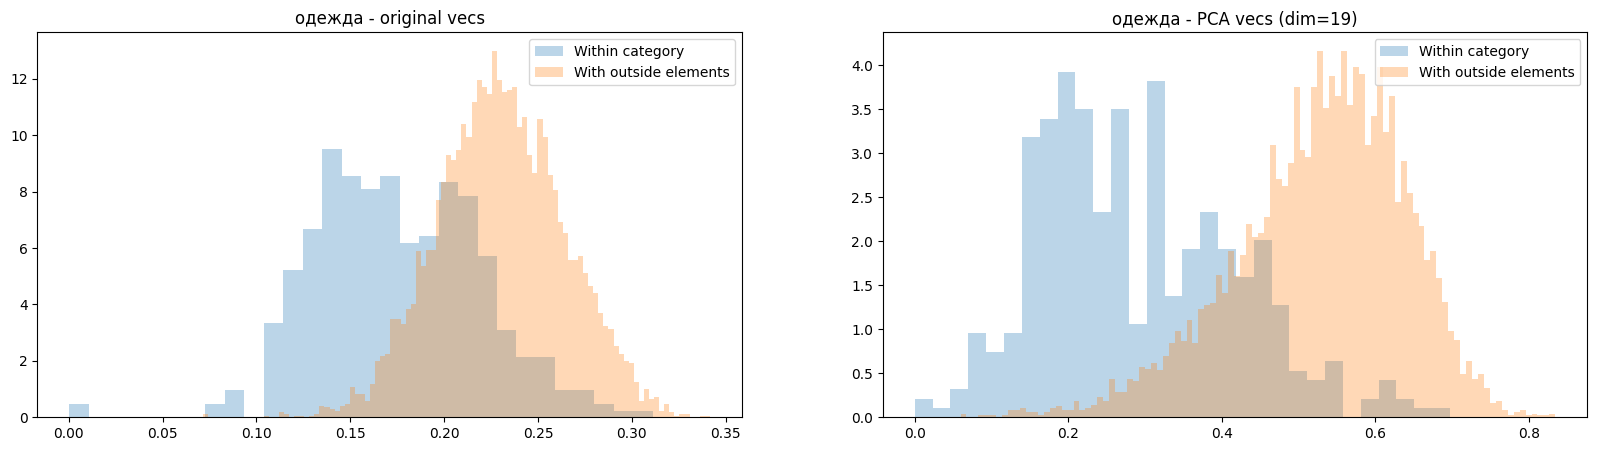

обувь [4 ads]: 0.153 - 0.183 (+2*0.021=0.225) - 0.221
	[TOO CLOSE] closest dist: 0.114 to advertisement 113, which is unmatched advertisement


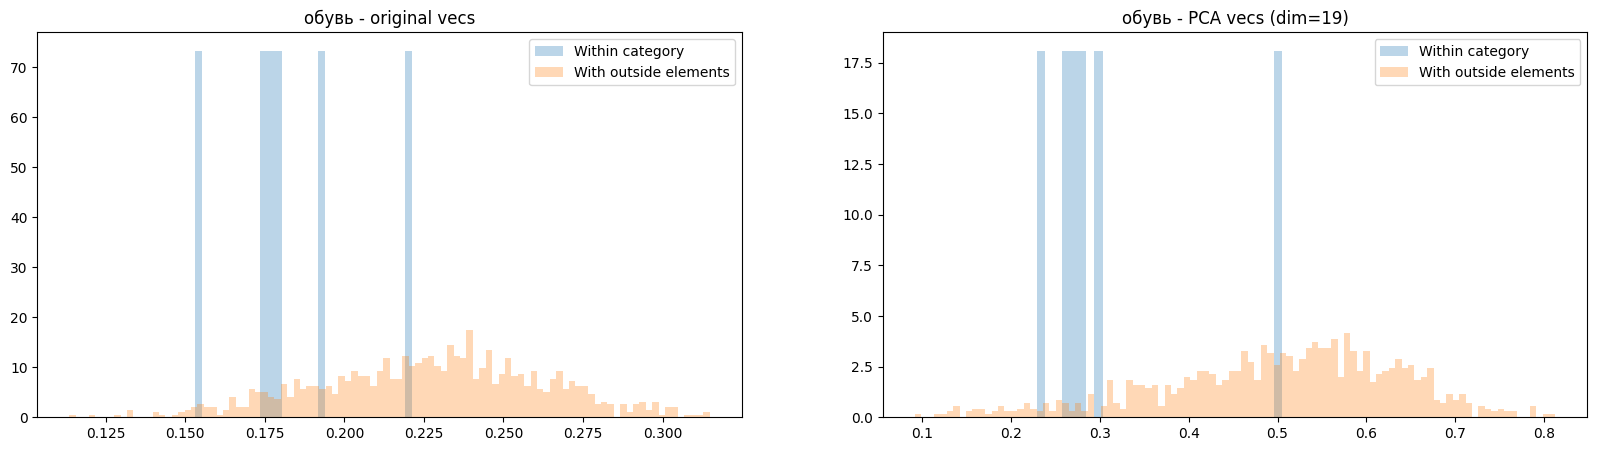

аксессуары [8 ads]: 0.029 - 0.183 (+2*0.046=0.275) - 0.238
	[TOO CLOSE] closest dist: 0.071 to advertisement 122, which is 'одежда'


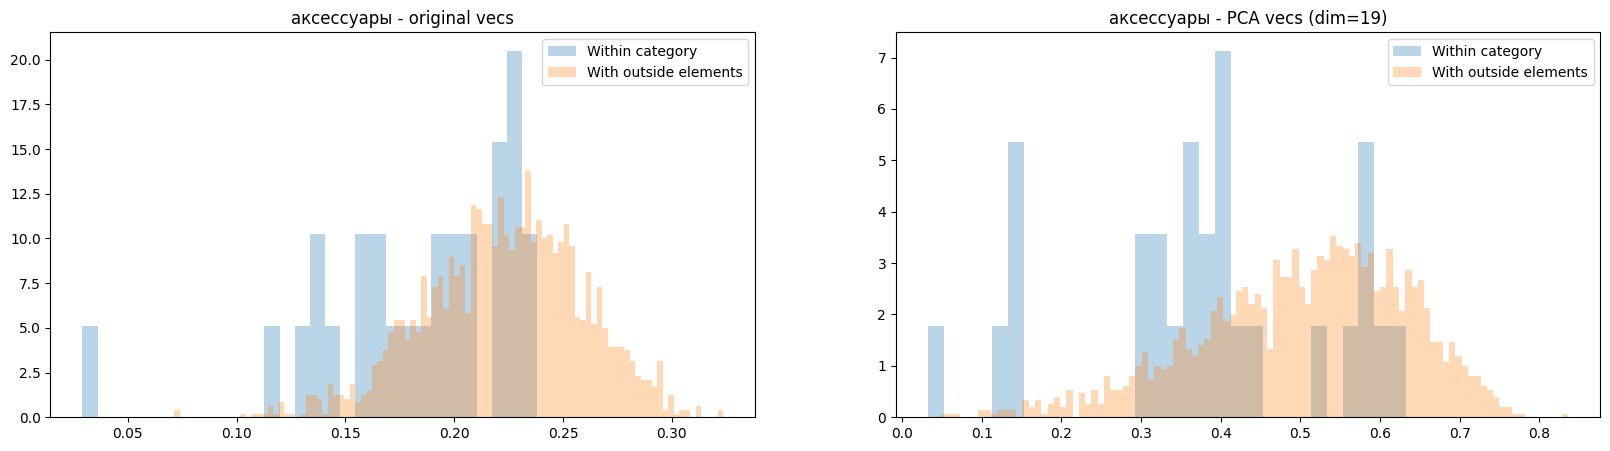

детское [8 ads]: 0.005 - 0.196 (+2*0.052=0.300) - 0.247
	[TOO CLOSE] closest dist: 0.092 to advertisement 43, which is 'одежда'


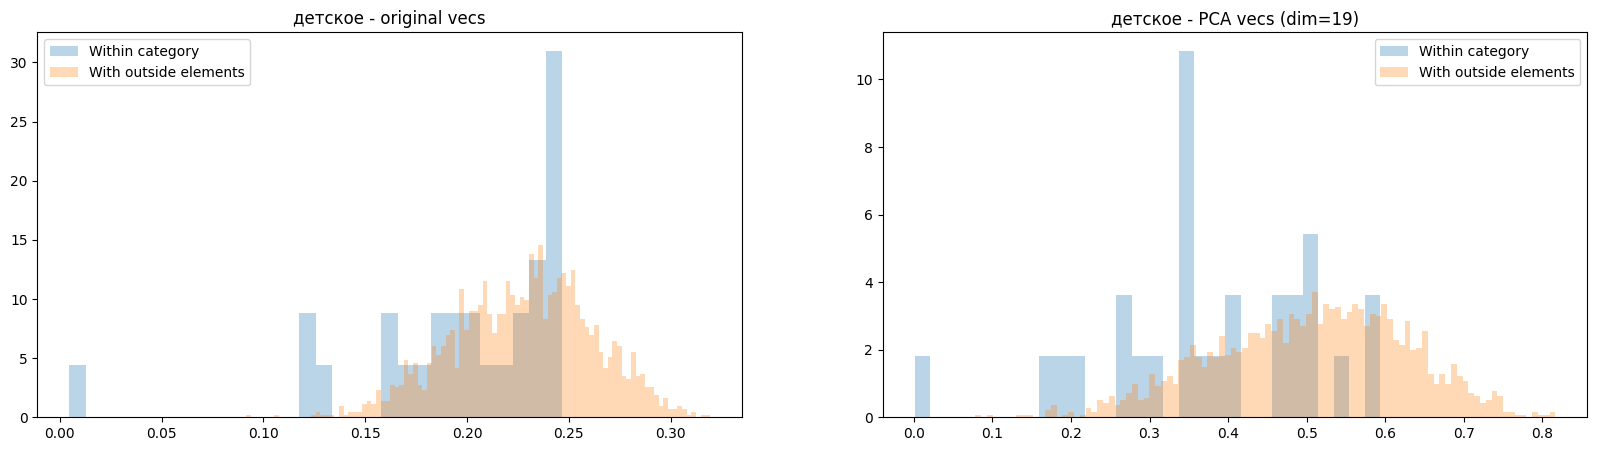

разное [13 ads]: 0.029 - 0.202 (+2*0.037=0.275) - 0.267
	[TOO CLOSE] closest dist: 0.102 to advertisement 124, which is unmatched advertisement


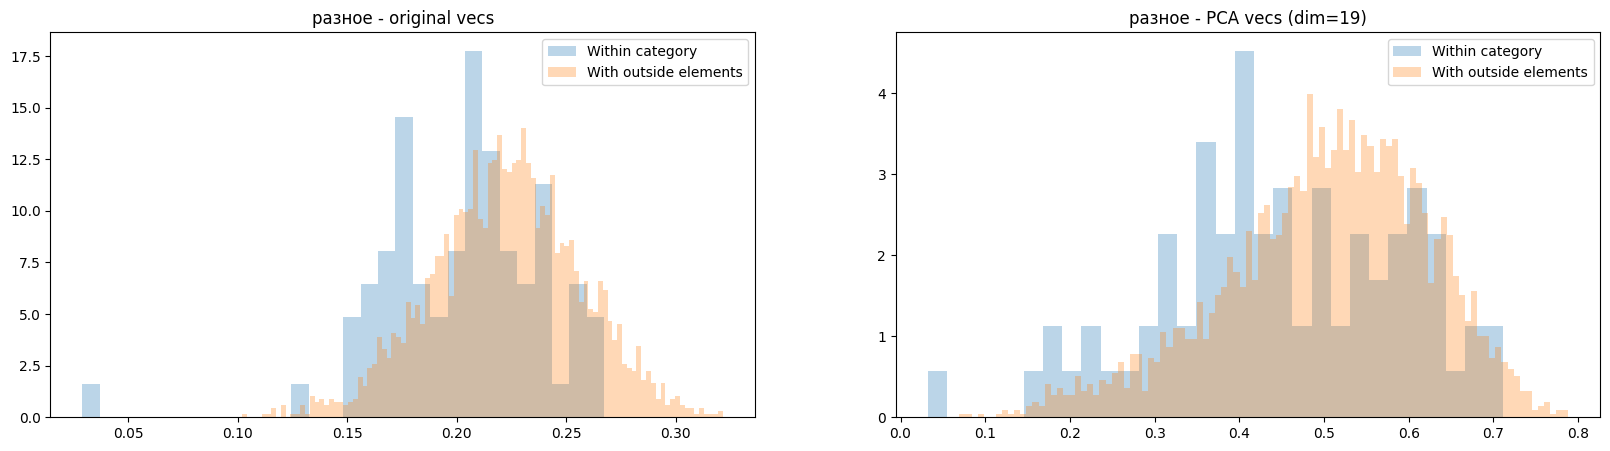

мебель [13 ads]: 0.008 - 0.189 (+2*0.038=0.266) - 0.263
	[TOO CLOSE] closest dist: 0.116 to advertisement 115, which is unmatched advertisement


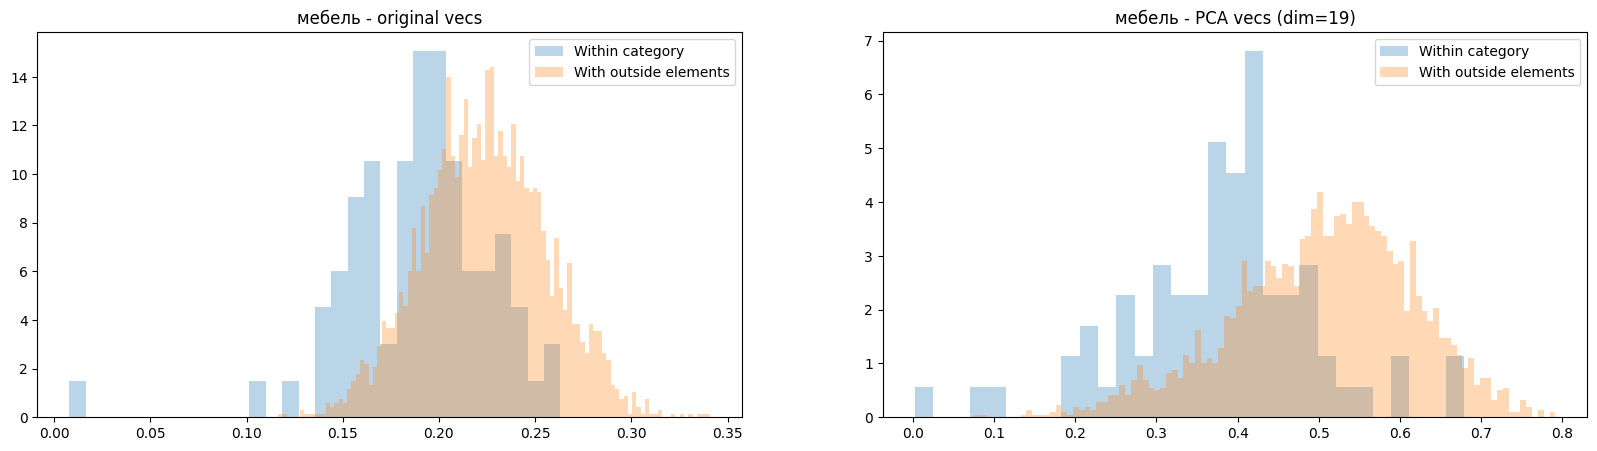

дача [19 ads]: 0.002 - 0.154 (+2*0.044=0.243) - 0.288
	[TOO CLOSE] closest dist: 0.065 to advertisement 28, which is 'рынок'


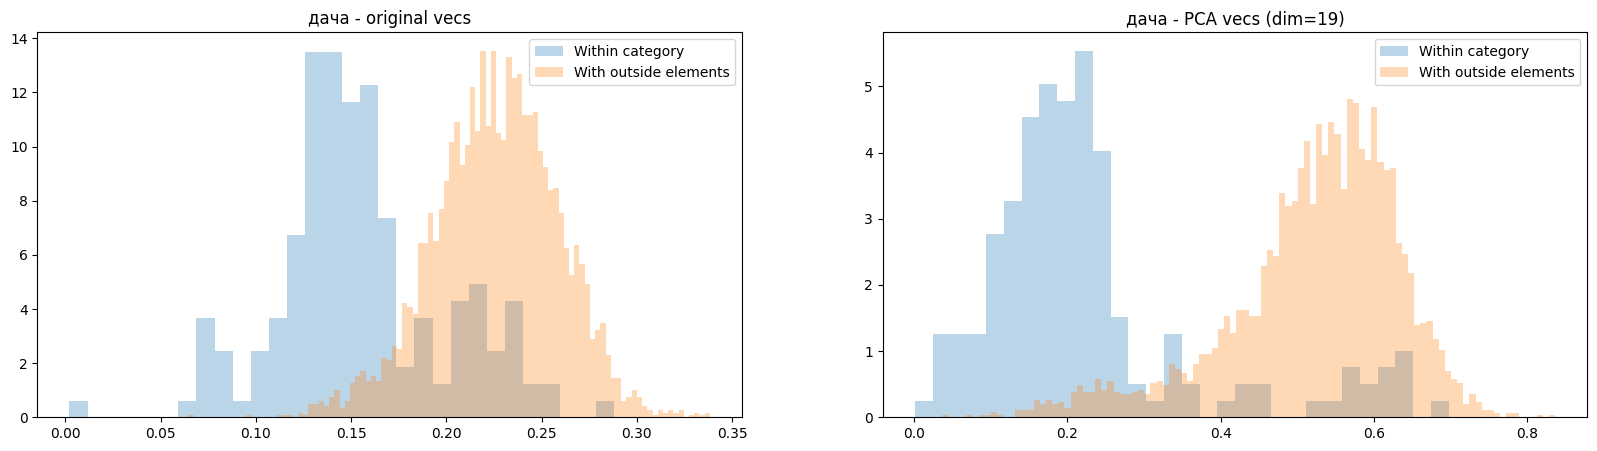

электроника [39 ads]: 0.040 - 0.213 (+2*0.050=0.312) - 0.318
	[TOO CLOSE] closest dist: 0.102 to advertisement 82, which is unmatched advertisement


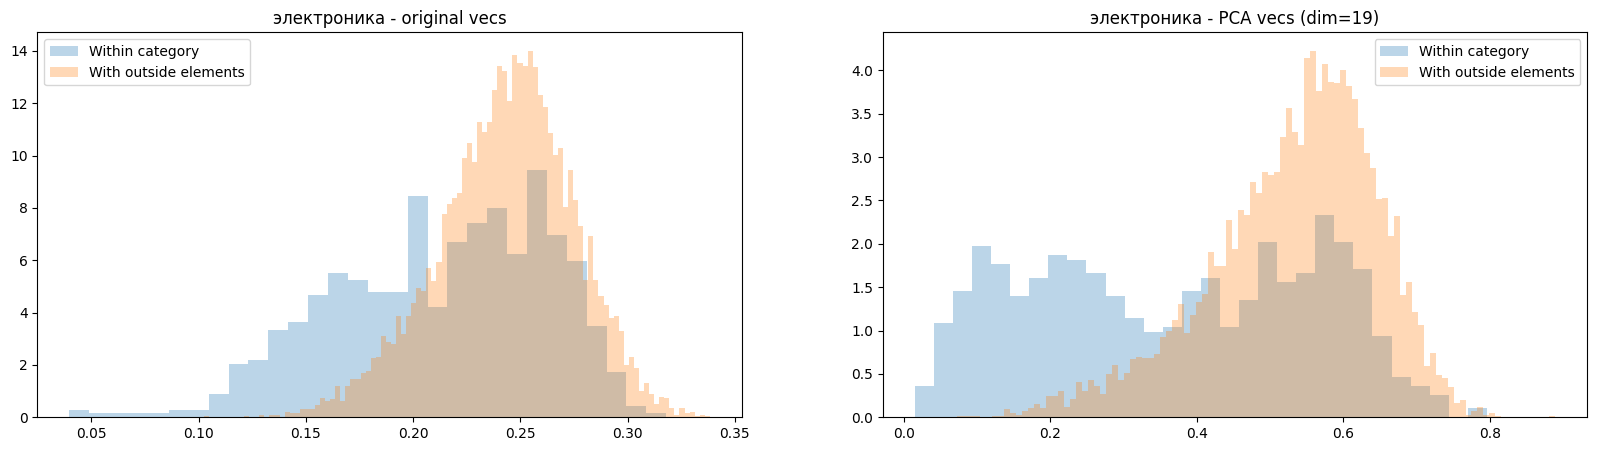

услуги [8 ads]: 0.115 - 0.235 (+2*0.034=0.304) - 0.297
	[TOO CLOSE] closest dist: 0.132 to advertisement 76, which is ['дача', 'рынок']


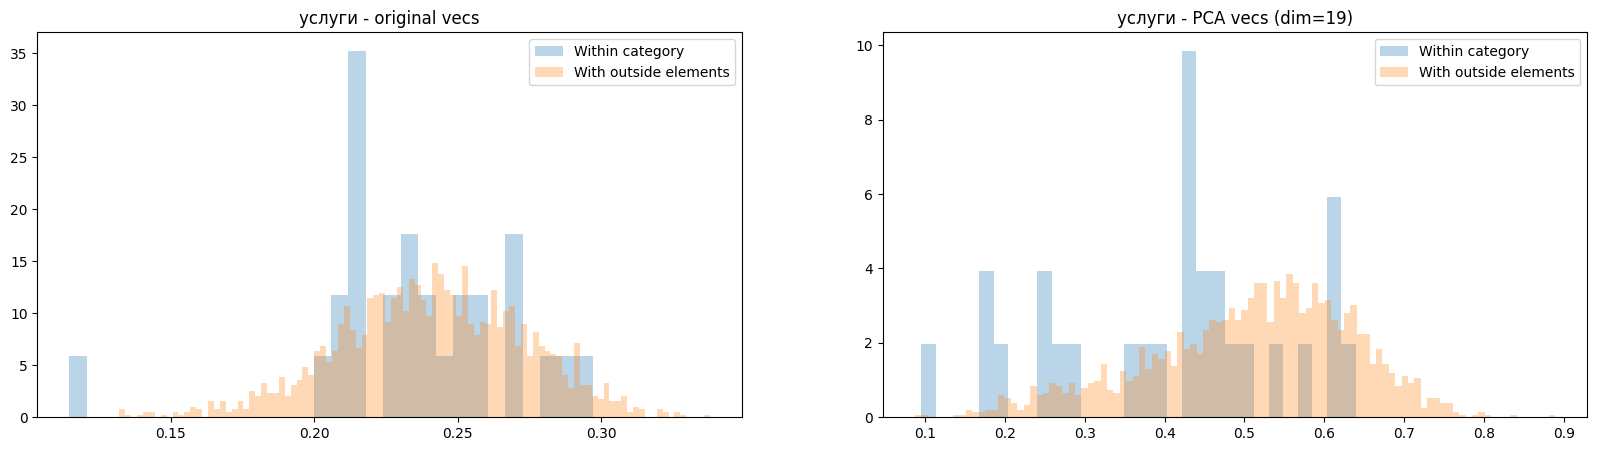

животные [29 ads]: 0.002 - 0.198 (+2*0.052=0.302) - 0.311
	[TOO CLOSE] closest dist: 0.070 to advertisement 178, which is 'дача'


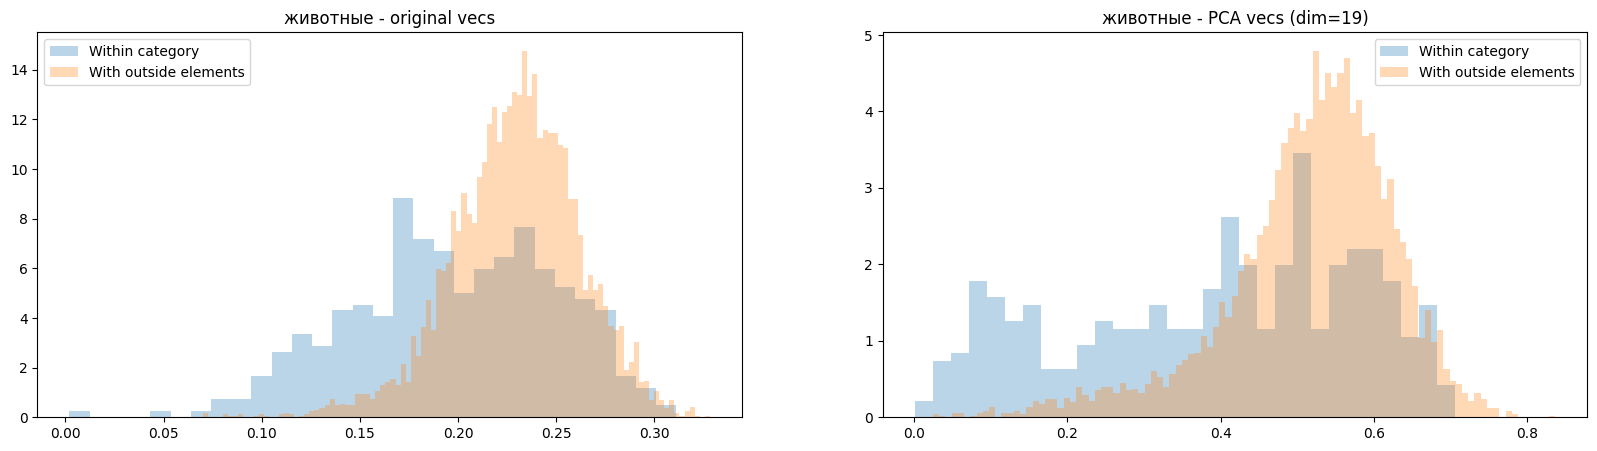

растения [9 ads]: 0.081 - 0.157 (+2*0.025=0.207) - 0.209
	[TOO CLOSE] closest dist: 0.123 to advertisement 163, which is 'дача'


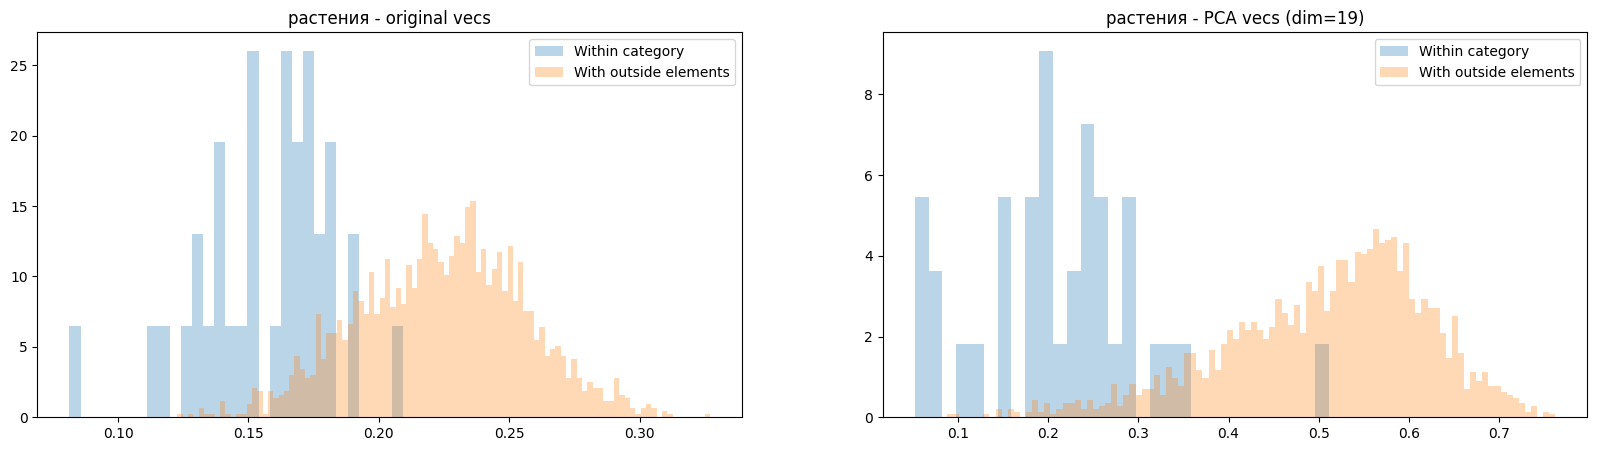

рынок [18 ads]: 0.002 - 0.158 (+2*0.035=0.229) - 0.252
	[TOO CLOSE] closest dist: 0.070 to advertisement 178, which is 'дача'


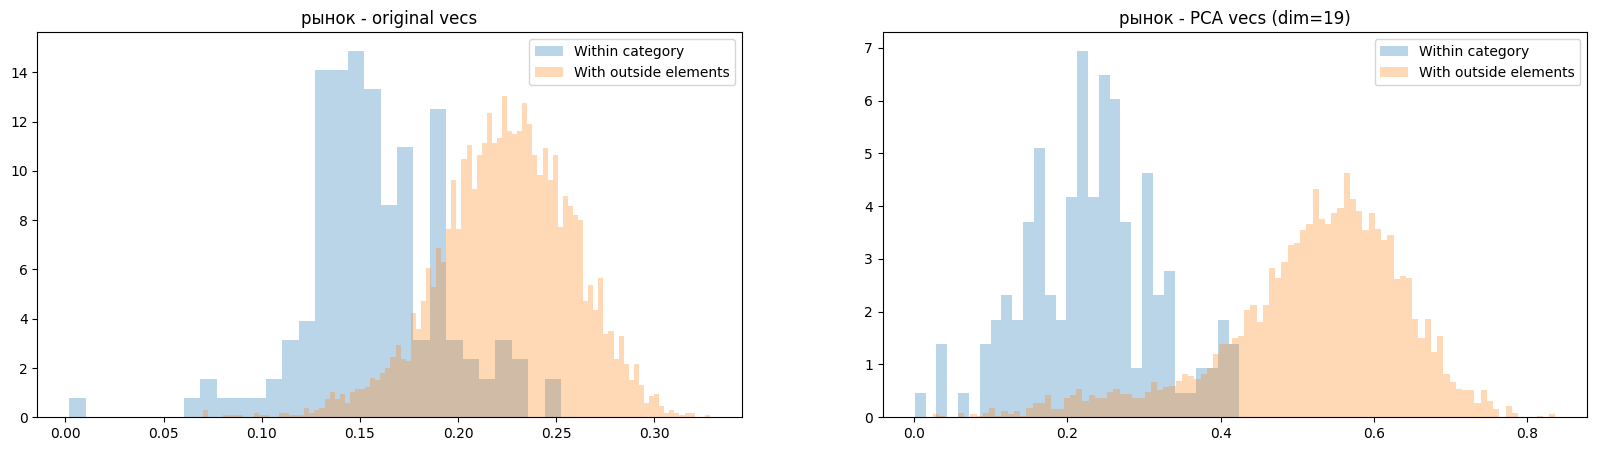

косметика [1 ads]: not enough statistic
	closest dist: 0.112 to advertisement 244, which is 'аксессуары'
автомобили [25 ads]: 0.001 - 0.136 (+2*0.034=0.204) - 0.240
	[TOO CLOSE] closest dist: 0.104 to advertisement 159, which is unmatched advertisement


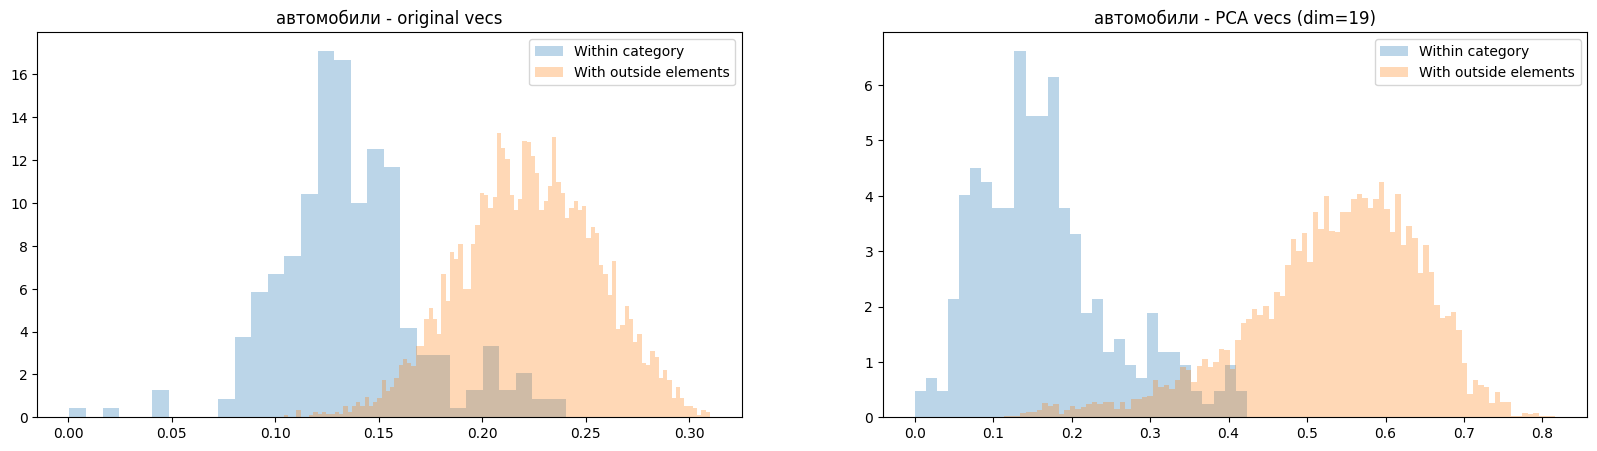





distance between centers of "одежда" and "обувь": 0.042
distance between centers of "одежда" and "аксессуары": 0.036
distance between centers of "одежда" and "детское": 0.067
distance between centers of "одежда" and "разное": 0.043
distance between centers of "одежда" and "мебель": 0.066
distance between centers of "одежда" and "дача": 0.098
distance between centers of "одежда" and "электроника": 0.101
distance between centers of "одежда" and "услуги": 0.096
distance between centers of "одежда" and "животные": 0.075
distance between centers of "одежда" and "растения": 0.102
distance between centers of "одежда" and "рынок": 0.096
distance between centers of "одежда" and "косметика": 0.157
distance between centers of "одежда" and "автомобили": 0.102
distance between centers of "обувь" and "аксессуары": 0.060
distance between centers of "обувь" and "детское": 0.084
distance between centers of "обувь" and "разное": 0.063
distance between centers of "обувь" and "мебель": 0.089
distance 

In [21]:
default_figsize = plt.rcParams['figure.figsize']
plt.rcParams['figure.figsize'] = (20, 5)

print("Distances per category")
req_mean_point_list = []
for req_name, req_lines in req_categories.items():
    cat_dists, other_dists = calc_int_ext_category_distances(req_lines, ad_embeddings)
    pca_cat_dists, pca_other_dists = calc_int_ext_category_distances(req_lines, pca_ad_embeddings)

    req_mean_vecs = []
    ad_lines = list(sorted(set(int(ad_line) - 1 for req_line in req_lines for ad_line in true_markup.get(str(req_line), []))))
    for first_ad_idx in range(0, len(ad_lines)):
        req_mean_vecs.append(ad_embeddings[ad_lines[first_ad_idx]])
    req_mean_point_list.append((req_name, np.asarray(req_mean_vecs).mean(axis=0)))

    closest_dist = None
    closest_ad_idx = None
    for ad_idx in range(0, len(ad_embeddings)):
        if ad_idx in ad_lines:
            continue
        for cat_ad_idx in ad_lines:
            dist = calc_distance(ad_embeddings[cat_ad_idx], ad_embeddings[ad_idx])
            if closest_dist is None or dist < closest_dist:
                closest_dist = dist
                closest_ad_idx = ad_idx

    closest_ad_cat_list = list(sorted(set(
        cat_name for cat_name, cat_lines in req_categories.items() for cat_line in cat_lines
        if str(closest_ad_idx + 1) in true_markup.get(str(cat_line), [])
    )))
    if len(closest_ad_cat_list) == 0:
        closest_ad_cat_str = "unmatched advertisement"
    elif len(closest_ad_cat_list) == 1:
        closest_ad_cat_str = repr(closest_ad_cat_list[0])
    else:
        closest_ad_cat_str = repr(closest_ad_cat_list)

    if cat_dists.size > 1:
        print(
            f"{req_name} [{len(ad_lines)} ads]: {cat_dists.min():.3f} - {cat_dists.mean():.3f} "
            f"(+2*{cat_dists.std():.3f}={cat_dists.mean() + 2*cat_dists.std():.3f}) "
            f"- {cat_dists.max():.3f}"
        )
    else:
        print(f"{req_name} [{len(ad_lines)} ads]: not enough statistic")

    if closest_dist is not None:
        if cat_dists.size > 0 and closest_dist <= cat_dists.max():
            warn_str = "[TOO CLOSE] "
        else:
            warn_str = ""
        print(f"\t{warn_str}closest dist: {closest_dist:.3f} to advertisement {closest_ad_idx}, which is {closest_ad_cat_str}")

    if cat_dists.size > 1 and other_dists.size > 1:
        fig, axs = plt.subplots(1, 2)
        axs[0].hist(cat_dists, bins=30, density=True, alpha=0.3, label="Within category")
        axs[0].hist(other_dists, bins=100, density=True, alpha=0.3, label="With outside elements")
        axs[0].set_title(f"{req_name} - original vecs")
        axs[0].legend()
        axs[1].hist(pca_cat_dists, bins=30, density=True, alpha=0.3, label="Within category")
        axs[1].hist(pca_other_dists, bins=100, density=True, alpha=0.3, label="With outside elements")
        axs[1].set_title(f"{req_name} - PCA vecs (dim={N_PCA_COMPONENTS})")
        axs[1].legend()
        plt.show()

print("\n\n\n")
for first_cat_idx in range(0, len(req_mean_point_list)):
    for second_cat_idx in range(first_cat_idx + 1, len(req_mean_point_list)):
        print(
            f"distance between centers of \"{req_mean_point_list[first_cat_idx][0]}\" and \"{req_mean_point_list[second_cat_idx][0]}\": "
            f"{calc_distance(req_mean_point_list[first_cat_idx][1], req_mean_point_list[second_cat_idx][1]):.3f}"
        )

plt.rcParams['figure.figsize'] = default_figsize

Only distance information is not enough for the clustering, so we have to use a classification algorithm to account vector areas in addition to the distance.

## Classification

In [22]:
REQ_NAME = "одежда"

pca = PCA(n_components=N_PCA_COMPONENTS)
pca_ad_embeddings = pca.fit_transform(ad_embeddings)

classes = []
cat_name_list = list(sorted(req_categories.keys()))
for ad_idx in range(len(ad_embeddings)):
    # ad_cat_list = list(sorted(set(
    #     cat_name for cat_name, cat_lines in req_categories.items() for cat_line in cat_lines
    #     if str(ad_idx + 1) in true_markup.get(str(cat_line), [])
    # )))
    ad_cat_list = list(set(REQ_NAME for cat_line in req_categories[REQ_NAME] if str(ad_idx + 1) in true_markup.get(str(cat_line), [])))
    if len(ad_cat_list) == 0:
        classes.append(-1)
    elif len(ad_cat_list) == 1:
        classes.append(cat_name_list.index(ad_cat_list[0]))
    else:
        # take class with less items
        cat_name = sorted([(cat_name, len(req_categories[cat_name])) for cat_name in ad_cat_list], key=lambda item: item[1])[0][0]
        classes.append(cat_name_list.index(cat_name))
classes = np.asarray(classes)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(ad_embeddings, classes, test_size=0.3, random_state=0)

clf = SVC()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [23]:
print(f"Accuracy: {sum(1 if y == y_t else 0 for y, y_t in zip(y_pred, y_test))/len(y_test)}")

Accuracy: 0.9324324324324325
